In [1]:
import time
t1 = time.time()

import scipy.special as sp
import scipy.stats as stats
import math
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from xgboost import XGBClassifier

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam , SGD , Adagrad
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers , initializers
from sklearn.metrics import confusion_matrix
import tensorflow.keras.backend as K
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

gpus = tf.config.experimental.list_physical_devices("GPU")
tf.config.set_visible_devices(gpus[0], "GPU")

### set seed ###
keras.utils.set_random_seed(2330)
tf.config.experimental.enable_op_determinism()

2026-03-26 10:08:31.030409: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [80]:
##### define some useful function

def significance_smallN(s, b):
    if s==0: return 0
    n_obs = s + b
    exact_p_value = sp.gammainc(n_obs, b)
    exact_z_score = stats.norm.isf(exact_p_value)
    if exact_z_score<0: return 0
    else: return exact_z_score

def significance(s,b):
    if b==s: return 0
    return np.sqrt(2*((s+b)*np.log(1+s/b)-s))

In [3]:
##### load signal data #####

hhvv_HLdata_path = "/root/data/mucollider/two_boosted/scan_kappa3_hhvv_HL.h5"
hhvv_HLdata_file = h5py.File(hhvv_HLdata_path, 'r')
print(hhvv_HLdata_file.keys())

hhvv_LLdata_path = "/root/data/mucollider/two_boosted/scan_kappa3_hhvv_LL.h5"
hhvv_LLdata_file = h5py.File(hhvv_LLdata_path, 'r')
print(hhvv_LLdata_file.keys())

hhmumu_HLdata_path = "/root/data/mucollider/two_boosted/scan_kappa3_hhmumu_HL.h5"
hhmumu_HLdata_file = h5py.File(hhmumu_HLdata_path, 'r')
print(hhmumu_HLdata_file.keys())

hhmumu_LLdata_path = "/root/data/mucollider/two_boosted/scan_kappa3_hhmumu_LL.h5"
hhmumu_LLdata_file = h5py.File(hhmumu_LLdata_path, 'r')
print(hhmumu_LLdata_file.keys())

##### load background data #####

HLdata_path = "/root/data/mucollider/two_boosted/test_HLfeature.h5"
HLdata_file = h5py.File(HLdata_path, 'r')
print(HLdata_file.keys())

LLdata_path = "/root/data/mucollider/two_boosted/test_LLfeature.h5"
LLdata_file = h5py.File(LLdata_path, 'r')
print(LLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['particle_info']>
<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['particle_info']>
<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_everytype', 'target_sigbg']>
<KeysViewHDF5 ['particle_info']>


In [4]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures = ['particle_info']

##### select BTag work point at WP70 (BitNumber 1) #####

hhvv_BTag_leading = ((hhvv_HLdata_file['BTag_leading'][:])&2)
hhvv_BTag_subleading = ((hhvv_HLdata_file['BTag_subleading'][:])&2)

hhmumu_BTag_leading = ((hhmumu_HLdata_file['BTag_leading'][:])&2)
hhmumu_BTag_subleading = ((hhmumu_HLdata_file['BTag_subleading'][:])&2)

BTag_leading = ((HLdata_file['BTag_leading'][:])&2)
BTag_subleading = ((HLdata_file['BTag_subleading'][:])&2)

##### include other high level features data #####
##### SIG data #####

print("hhvv scan kappa3 data:")
hhvv_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhvv_HLdata.append(hhvv_BTag_leading)
    elif feature=='BTag_subleading': hhvv_HLdata.append(hhvv_BTag_subleading)
    else: hhvv_HLdata.append(hhvv_HLdata_file[feature][:])
hhvv_HLdata = np.array(hhvv_HLdata).T
print('shape of high level data:', hhvv_HLdata.shape)

hhvv_LLdata = hhvv_LLdata_file['particle_info'][:]
print('shape of low level data:', hhvv_LLdata.shape)

print("hhmumu scan kappa3 data:")
hhmumu_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhmumu_HLdata.append(hhmumu_BTag_leading)
    elif feature=='BTag_subleading': hhmumu_HLdata.append(hhmumu_BTag_subleading)
    else: hhmumu_HLdata.append(hhmumu_HLdata_file[feature][:])
hhmumu_HLdata = np.array(hhmumu_HLdata).T
print('shape of high level data:', hhmumu_HLdata.shape)

hhmumu_LLdata = hhmumu_LLdata_file['particle_info'][:]
print('shape of low level data:', hhmumu_LLdata.shape)

##### BG data #####

print("BG data:")
HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': HLdata.append(BTag_leading)
    elif feature=='BTag_subleading': HLdata.append(BTag_subleading)
    else: HLdata.append(HLdata_file[feature][:])
HLdata = np.array(HLdata).T
print('shape of high level data:', HLdata.shape)

LLdata = LLdata_file['particle_info'][:]
print('shape of low level data:', LLdata.shape)

hhvv scan kappa3 data:
shape of high level data: (321016, 16)
shape of low level data: (321016, 160)
hhmumu scan kappa3 data:
shape of high level data: (314674, 16)
shape of low level data: (314674, 160)
BG data:
shape of high level data: (347538, 16)
shape of low level data: (347538, 160)


In [5]:
##### load the model #####

sigbg_DNN = models.load_model("/root/data/mucollider/two_boosted/ML_model/model_mucollider_v2.h5")

scan_xgb_0416 = XGBClassifier()
scan_xgb_0416.load_model("/root/data/mucollider/two_boosted/ML_model/xgb_0416_v1.json")

2026-03-26 10:08:34.038066: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46696 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
##### define the event information #####

BR_hbb = 0.5824
Luminosity = 1000   ### unit: fb^-1
SIG_simulation_num = 100000
kappa3 = [0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8]

hhvv_Xsection_NoDecay = [1.23322e-01, 1.016366e-01, 8.33476424e-02, 6.81961e-02, 6.2211286e-02, 5.648398e-02, 5.187586e-02, 4.801255e-02, 4.246736e-02, 4.038406e-02, 4.1308219e-02]     ### hhvv unit: fb
hhvv_Xsection = [hhvv_Xsection_NoDecay[i]*BR_hbb*BR_hbb for i in range(11)]
hhvv_event_num = [31536, 31077, 30923, 30485, 30011, 29716, 29039, 28528, 27438, 26495, 25768]

hhmumu_Xsection_NoDecay = [1.068573e-2, 8.89267e-3, 7.29573e-3, 5.892737e-3, 5.2836183e-3, 4.68848e-3, 4.1895e-3, 3.7137245e-3, 2.9218193e-3, 2.3228e-3, 1.9414667e-3]     ### hhmumu unit: fb
hhmumu_Xsection = [hhmumu_Xsection_NoDecay[i]*BR_hbb*BR_hbb for i in range(11)]
hhmumu_event_num = [30469, 30020, 29858, 29497, 29190, 28845, 28653, 28343, 27442, 26613, 25744]

processes = ["hhvv", "hhmumu", "jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
BG_processes = ["jjBG_ptcut", "ttBG_ptcut", "bbBG_ptcut", "wwBG", "wwvvBG", "zzBG", "zzvvBG", "hzvvBG"]
event_num = [59247, 57847, 14119, 14298, 15633, 20285, 40078, 24300, 48454, 53277]
Xsection = [5.6572451e-02*BR_hbb*BR_hbb, 4.758146e-03*BR_hbb*BR_hbb, 1.345440e+01, 4.423700e+00, 2.325600e+00, 1.507183e+02, 1.223107e+01, 9.617100e+00, 6.469436e+00, 1.27619546e+00*BR_hbb]     ### unit: fb
BG_Xsection = Xsection[2:]
BG_simulation_num = 200000
Luminosity = 1000   ### unit: fb^-1

### model test ###

hhvv_HLtest = []
hhvv_LLtest = []
hhvv_sigbg_prediction = []
hhvv_scan_prediction = []

hhmumu_HLtest = []
hhmumu_LLtest = []
hhmumu_sigbg_prediction = []
hhmumu_scan_prediction = []

print("Do the prediction of hhvv signal data")
count = 0
for kappa3_val in kappa3:
    hhvv_HLtest.append(hhvv_HLdata[count:count+hhvv_event_num[kappa3.index(kappa3_val)]])
    hhvv_LLtest.append(hhvv_LLdata[count:count+hhvv_event_num[kappa3.index(kappa3_val)]])
    hhvv_sigbg_prediction.append(sigbg_DNN.predict([hhvv_HLtest[-1], hhvv_LLtest[-1]]).flatten())
    hhvv_scan_prediction.append(scan_xgb_0416.predict_proba(hhvv_HLtest[-1])[:,1])
    count += hhvv_event_num[kappa3.index(kappa3_val)]

print("\nDo the prediction of hhmumu signal data")
count = 0
for kappa3_val in kappa3:
    hhmumu_HLtest.append(hhmumu_HLdata[count:count+hhmumu_event_num[kappa3.index(kappa3_val)]])
    hhmumu_LLtest.append(hhmumu_LLdata[count:count+hhmumu_event_num[kappa3.index(kappa3_val)]])
    hhmumu_sigbg_prediction.append(sigbg_DNN.predict([hhmumu_HLtest[-1], hhmumu_LLtest[-1]]).flatten())
    hhmumu_scan_prediction.append(scan_xgb_0416.predict_proba(hhmumu_HLtest[-1])[:,1])
    count += hhmumu_event_num[kappa3.index(kappa3_val)]

BG_HLtest = []
BG_LLtest = []
BG_sigbg_prediction = []
BG_scan_prediction = []

print("\nDo the prediction of background data")
count = 0
for process in processes:
    if process in ["hhvv", "hhmumu"]:
        count += event_num[processes.index(process)]
        continue
    BG_HLtest.append(HLdata[count:count+event_num[processes.index(process)]])
    BG_LLtest.append(LLdata[count:count+event_num[processes.index(process)]])
    BG_sigbg_prediction.append(sigbg_DNN.predict([BG_HLtest[-1], BG_LLtest[-1]]).flatten())
    BG_scan_prediction.append(scan_xgb_0416.predict_proba(BG_HLtest[-1])[:,1])
    count += event_num[processes.index(process)]

Do the prediction of hhvv signal data
 85/986 [=>............................] - ETA: 1s

2026-03-26 10:08:36.034752: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


806/806 [==============================] - 1s 2ms/step

Do the prediction of hhmumu signal data
805/805 [==============================] - 1s 2ms/step

Do the prediction of background data
1665/1665 [==============================] - 3s 2ms/step


In [54]:
##### transform prediction score into 2D histogram #####

grid_num = 10

bins_x = np.linspace(0,1,grid_num+1)
bins_y = np.linspace(0,1,grid_num+1)

hhvv_counts = []
hhmumu_counts = []
BG_counts = []
for kappa3_val in kappa3:
    hhvv_counts.append(np.histogram2d(hhvv_sigbg_prediction[kappa3.index(kappa3_val)], hhvv_scan_prediction[kappa3.index(kappa3_val)], bins=[bins_x, bins_y])[0].T)
    hhmumu_counts.append(np.histogram2d(hhmumu_sigbg_prediction[kappa3.index(kappa3_val)], hhmumu_scan_prediction[kappa3.index(kappa3_val)], bins=[bins_x, bins_y])[0].T)
for process in BG_processes:
    BG_counts.append(np.histogram2d(BG_sigbg_prediction[BG_processes.index(process)], BG_scan_prediction[BG_processes.index(process)], bins=[bins_x, bins_y])[0].T)

##### calculate background event numbers #####

BG_event_num = np.zeros((grid_num, grid_num))
for process in BG_processes:
    BG_event_num += BG_Xsection[BG_processes.index(process)]*(BG_counts[BG_processes.index(process)]/BG_simulation_num)*Luminosity

##### calculate signal event numbers #####

sig_event_nums = []
for kappa3_val in kappa3:
    tmp_event_num = hhvv_Xsection[kappa3.index(kappa3_val)]*(hhvv_counts[kappa3.index(kappa3_val)]/SIG_simulation_num)*Luminosity + hhmumu_Xsection[kappa3.index(kappa3_val)]*(hhmumu_counts[kappa3.index(kappa3_val)]/SIG_simulation_num)*Luminosity
    sig_event_nums.append(tmp_event_num)
    del tmp_event_num

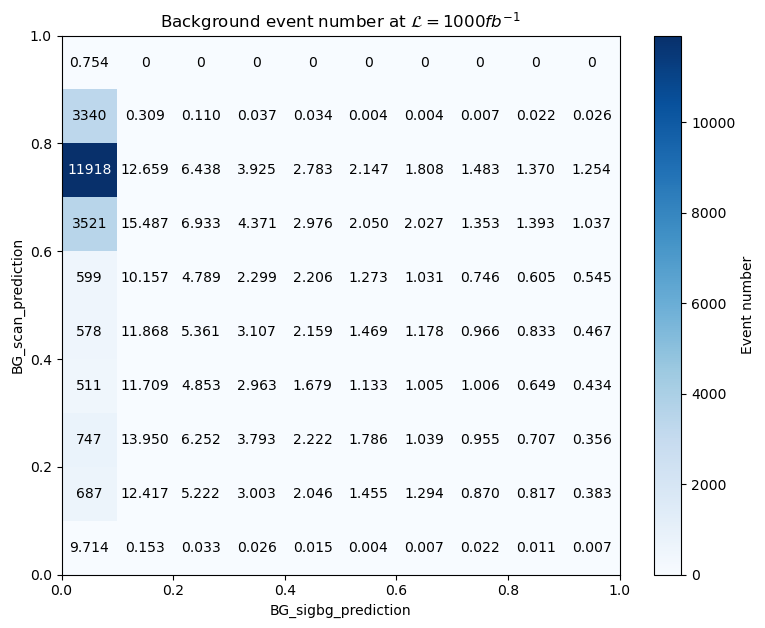

In [73]:
##### plot background event number #####

plt.figure(figsize=(9,7))
im = plt.pcolormesh(bins_x, bins_y, BG_event_num, cmap='Blues')
max_count = BG_event_num.max()
for i in range(len(bins_x) - 1):
    for j in range(len(bins_y) - 1):
        count = BG_event_num[j, i]
        x_center = (bins_x[i] + bins_x[i+1]) / 2
        y_center = (bins_y[j] + bins_y[j+1]) / 2
        text_color = "white" if count > (max_count / 2) else "black"
        plt.text(
            x_center, y_center, 
            f"{count:.0f}" if (count>100 or count==0) else f"{count:.3f}", 
            ha='center', 
            va='center', 
            color=text_color,
            fontsize=10
        )
plt.colorbar(im, label='Event number')
plt.xlabel('BG_sigbg_prediction')
plt.ylabel('BG_scan_prediction')
plt.title("Background event number at $\mathcal{L}=1000 fb^{-1}$")
plt.show()

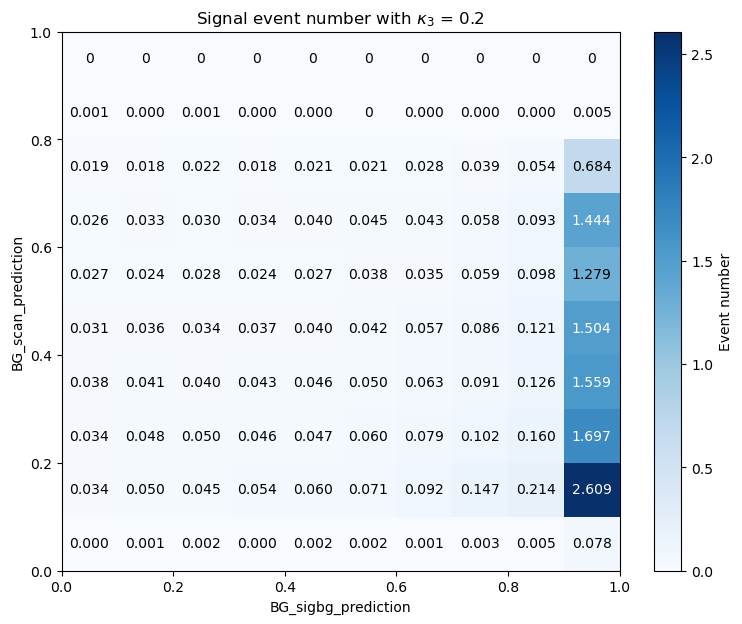

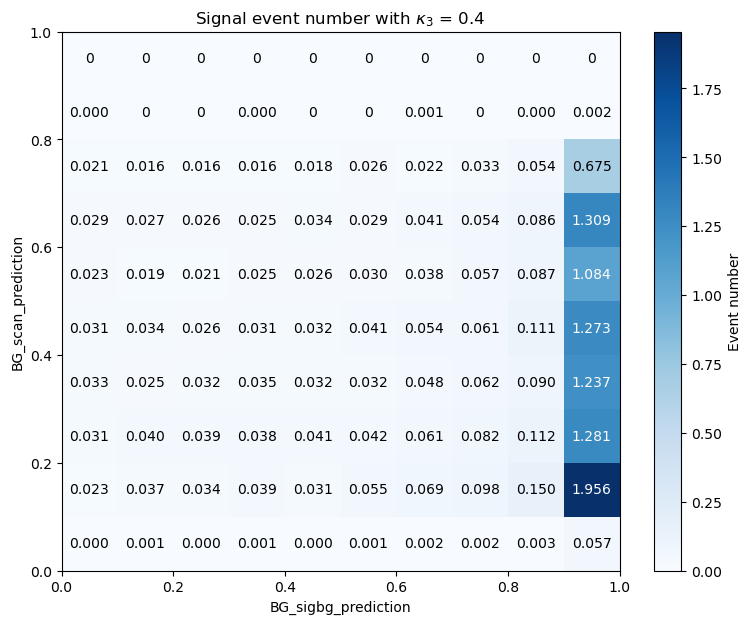

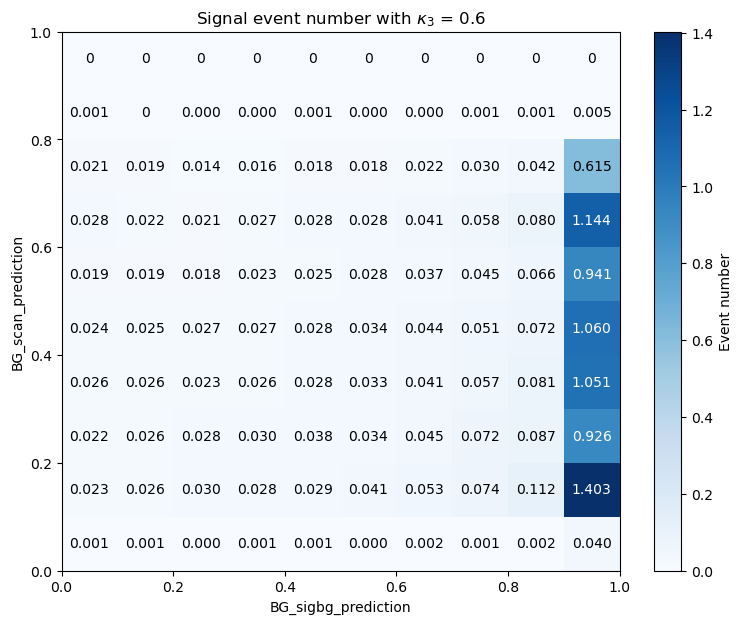

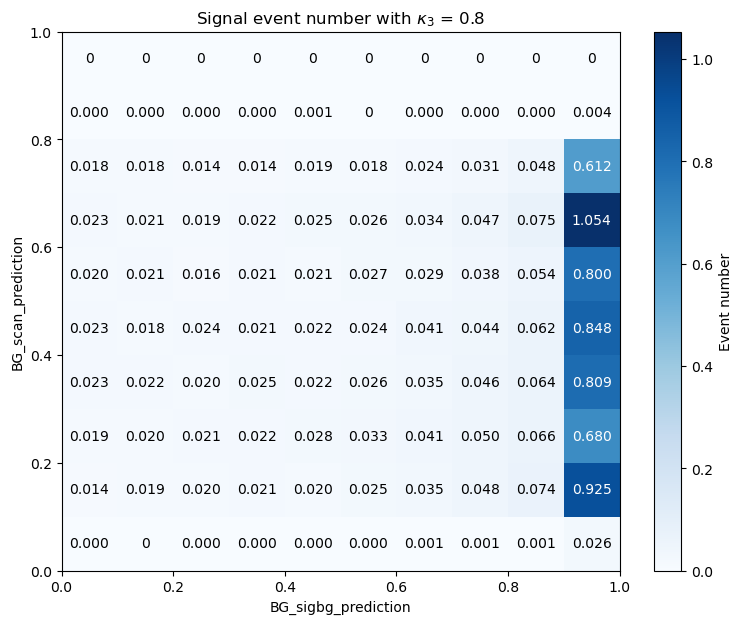

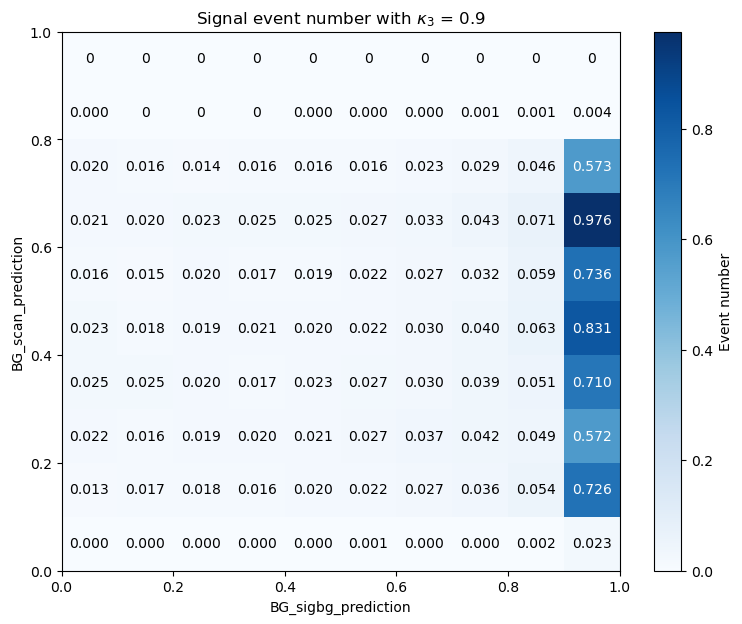

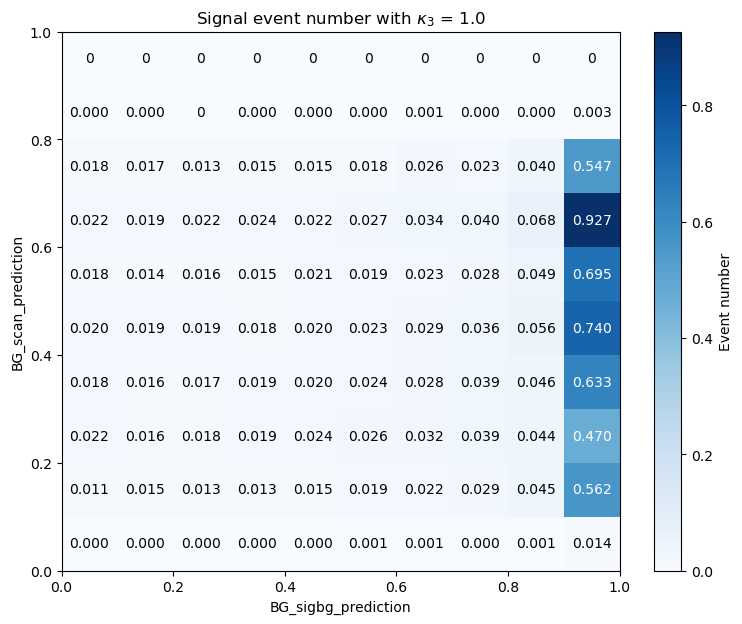

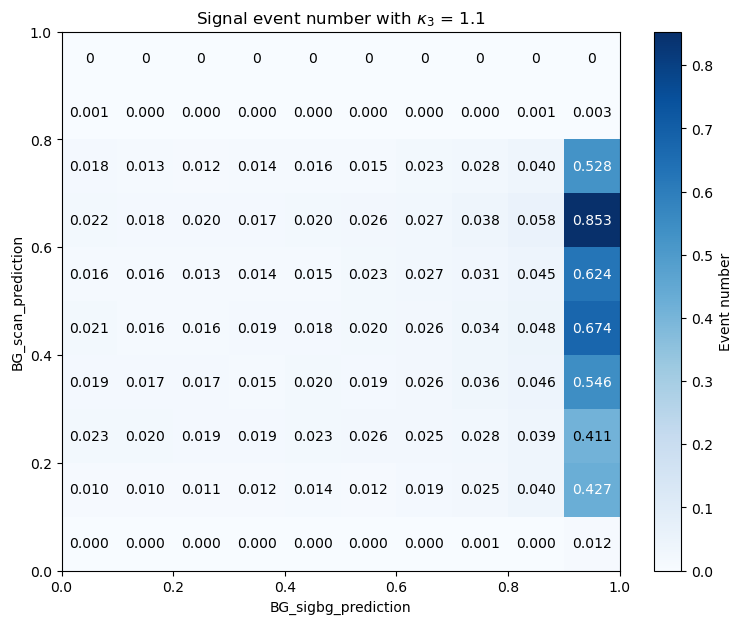

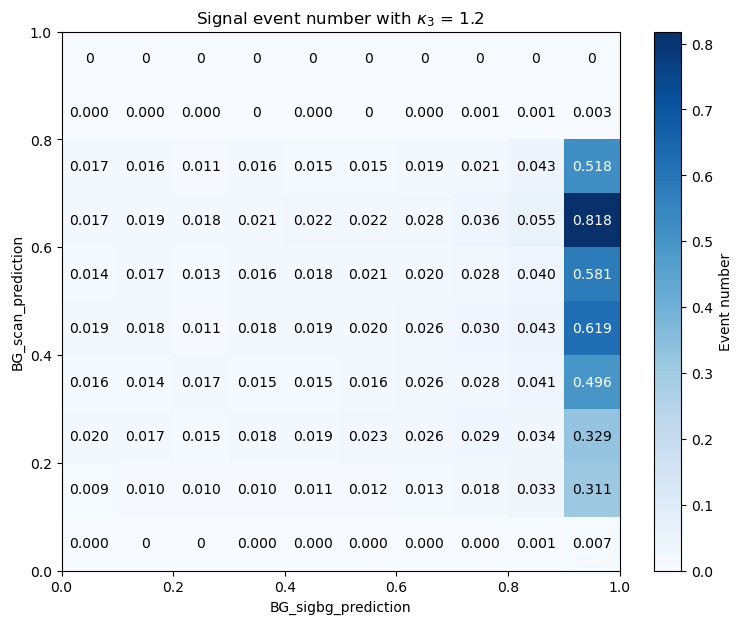

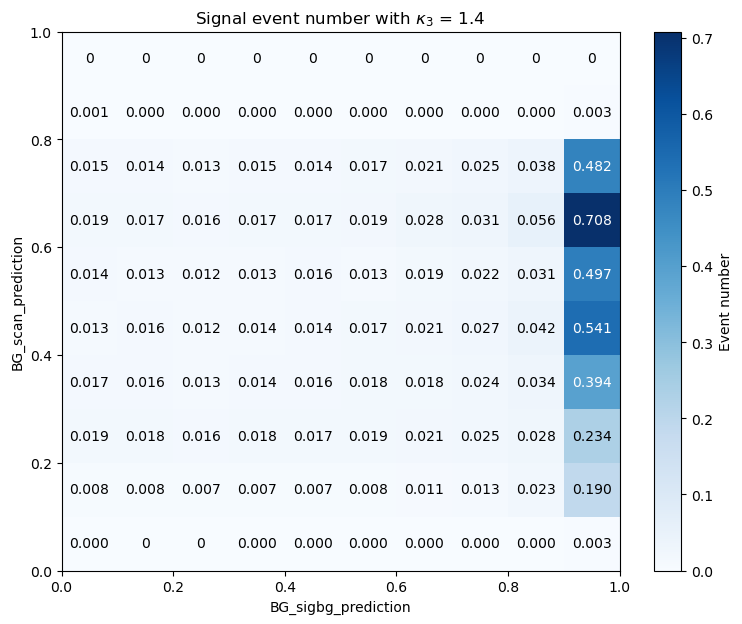

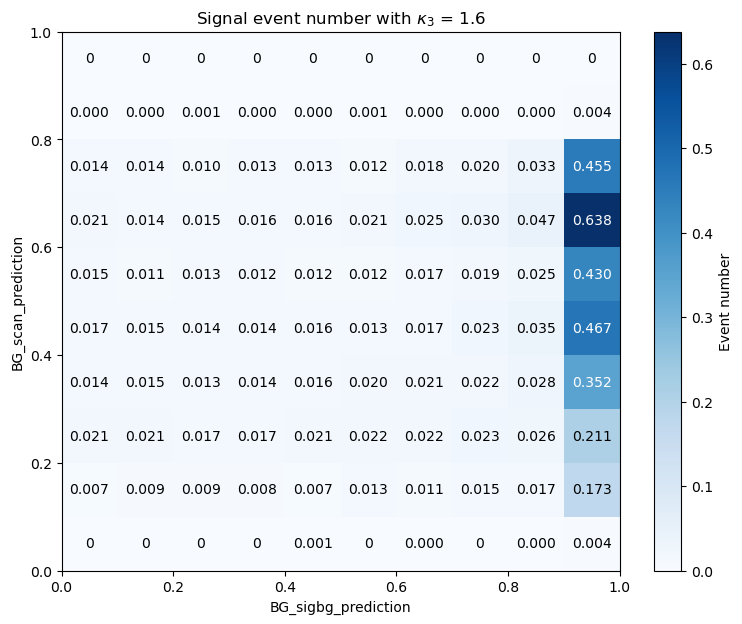

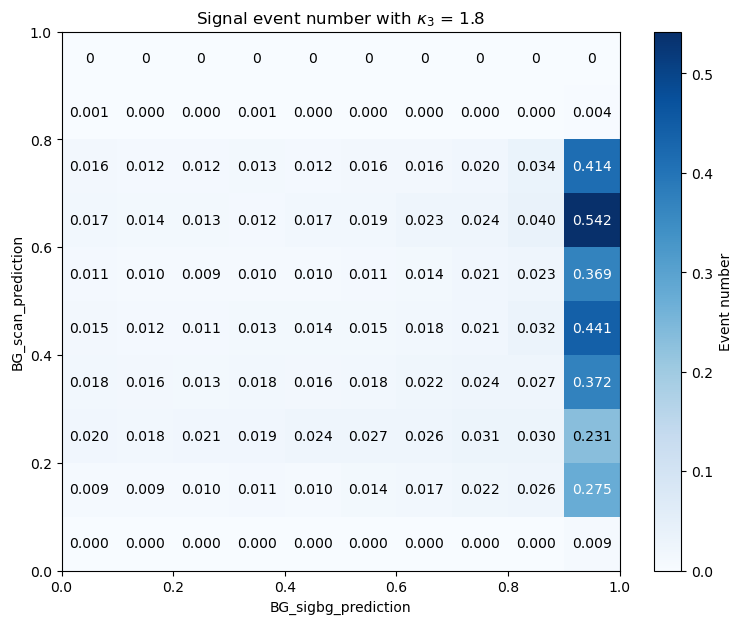

In [74]:
##### plot signal event number #####

for kappa3_val in kappa3:
    plt.figure(figsize=(9,7))
    im = plt.pcolormesh(bins_x, bins_y, sig_event_nums[kappa3.index(kappa3_val)], cmap='Blues')
    max_count = sig_event_nums[kappa3.index(kappa3_val)].max()
    for i in range(len(bins_x) - 1):
        for j in range(len(bins_y) - 1):
            count = sig_event_nums[kappa3.index(kappa3_val)][j, i]
            x_center = (bins_x[i] + bins_x[i+1]) / 2
            y_center = (bins_y[j] + bins_y[j+1]) / 2
            text_color = "white" if count > (max_count / 2) else "black"
            plt.text(
                x_center, y_center, 
                f"{count:.0f}" if (count>100 or count==0) else f"{count:.3f}", 
                ha='center', 
                va='center', 
                color=text_color,
                fontsize=10
            )
    plt.colorbar(im, label='Event number')
    plt.xlabel('BG_sigbg_prediction')
    plt.ylabel('BG_scan_prediction')
    plt.title(f"Signal event number with $\kappa_3$ = {kappa3_val}")
    plt.show()

In [90]:
Z_2D = []
Z_2D_simplified = []

for kappa3_val in kappa3:
    Zsq_total = 0
    Zsq_total_sim = 0
    for i in range(grid_num):
        for j in range(grid_num):
            Z = significance_smallN(sig_event_nums[kappa3.index(kappa3_val)][j][i], BG_event_num[j][i])
            Z_sim = significance(sig_event_nums[kappa3.index(kappa3_val)][j][i], BG_event_num[j][i])
            Zsq_total += Z**2
            Zsq_total_sim += Z_sim**2
    Z_2D.append(np.sqrt(Zsq_total))
    Z_2D_simplified.append(np.sqrt(Zsq_total_sim))

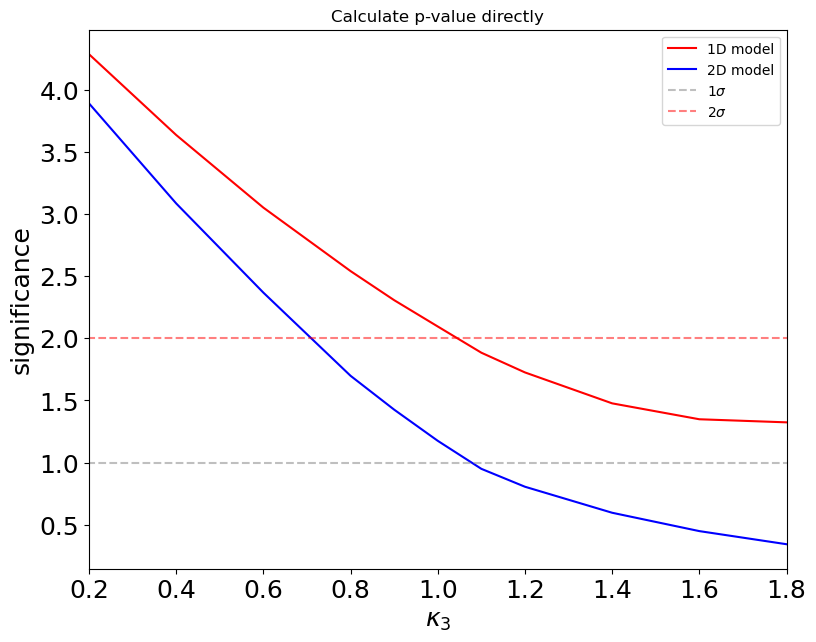

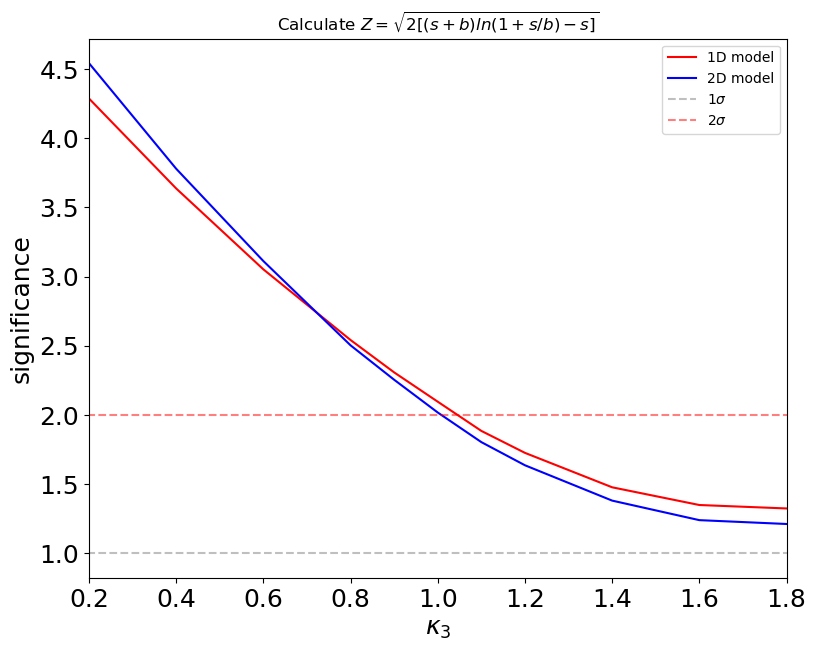

In [92]:
Z_1D = [4.287236718047947, 3.63677891055936, 3.0520763984291515, 2.54119526143928, 2.307191347773848, 2.095264983504354, 1.8842220785194639, 1.7255527398865806, 1.4765915461418766, 1.3485447737486704, 1.3236774728539829]

plt.figure(1, figsize=(9,7))
plt.plot(kappa3, Z_1D, color='r', label='1D model')
plt.plot(kappa3, Z_2D, color='b', label='2D model')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.xlim(0.2,1.8)
plt.hlines(1, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"1$\sigma$")
plt.hlines(2, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"2$\sigma$")
plt.title("Calculate p-value directly")
plt.legend()
plt.show()

plt.figure(1, figsize=(9,7))
plt.plot(kappa3, Z_1D, color='r', label='1D model')
plt.plot(kappa3, Z_2D_simplified, color='b', label='2D model')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel(r"$\kappa_3$", fontsize=18)
plt.ylabel(r"significance", fontsize=18)
plt.xlim(0.2,1.8)
plt.hlines(1, -10, 10, color='gray', alpha=0.5, linestyle="--", label=r"1$\sigma$")
plt.hlines(2, -10, 10, color='red', alpha=0.5, linestyle="--", label=r"2$\sigma$")
plt.title("Calculate $Z = \sqrt{2 [ (s+b) ln (1+s/b) -s ]}$")
plt.legend()
plt.show()